## Importing Libraries

In [33]:
# 1 Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score , recall_score , f1_score

In [34]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')

In [35]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## Data Analysis

In [36]:
df.shape

(1014, 7)

In [37]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [39]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [9]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [51]:
# data cleaning

In [10]:
# handling null values
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

<Axes: >

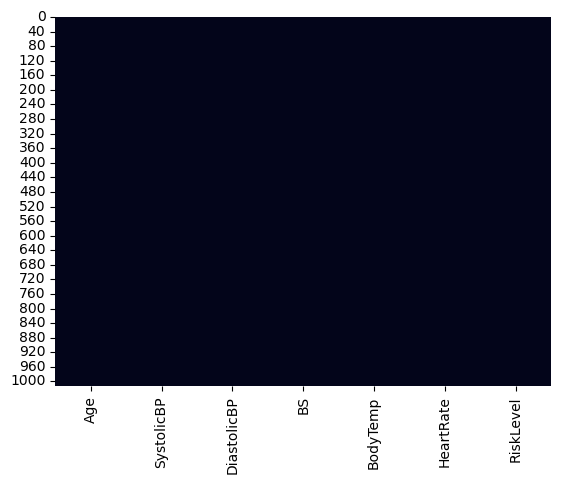

In [11]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)

In [32]:
# # handlind duplicates
# df.duplicated().sum()
# df = df.drop_duplicates()

In [13]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [14]:
df['RiskLevel'].value_counts()

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64

<Axes: xlabel='RiskLevel', ylabel='count'>

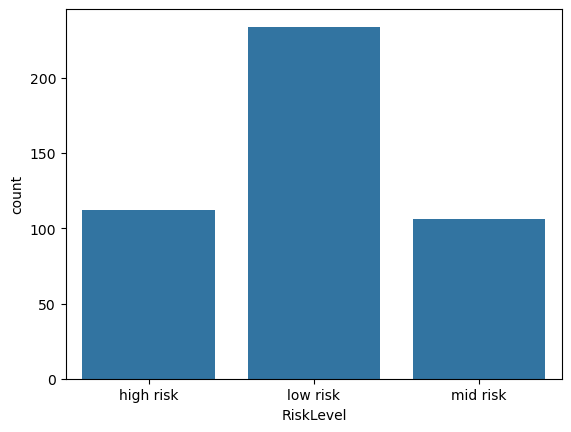

In [15]:
# distribution of the target column
sns.countplot(x='RiskLevel', data=df)

### EDA

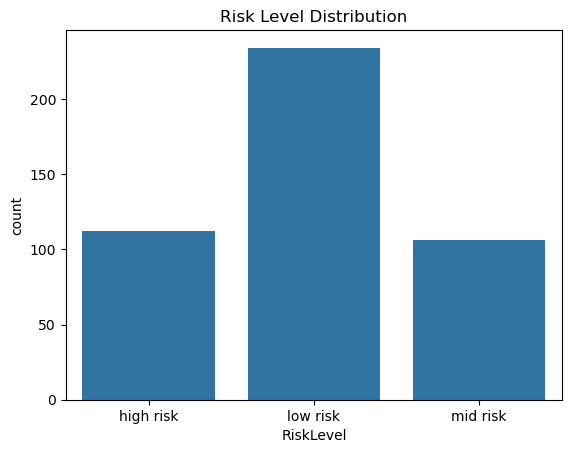

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="RiskLevel", data=df)

plt.title("Risk Level Distribution")

plt.show()

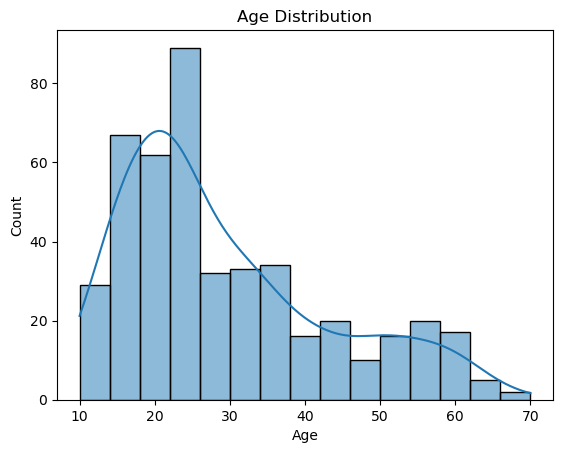

In [17]:
sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")

plt.show()

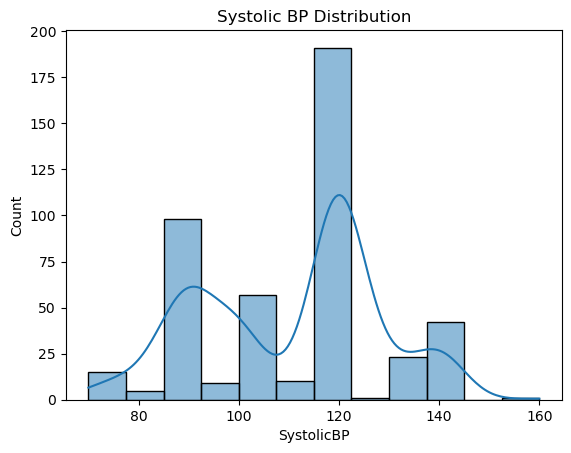

In [18]:
sns.histplot(df["SystolicBP"], kde=True)

plt.title("Systolic BP Distribution")

plt.show()

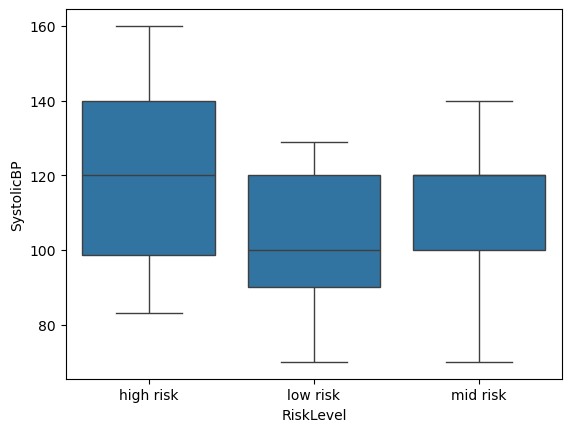

In [19]:
sns.boxplot(x="RiskLevel", y="SystolicBP", data=df)

plt.show()

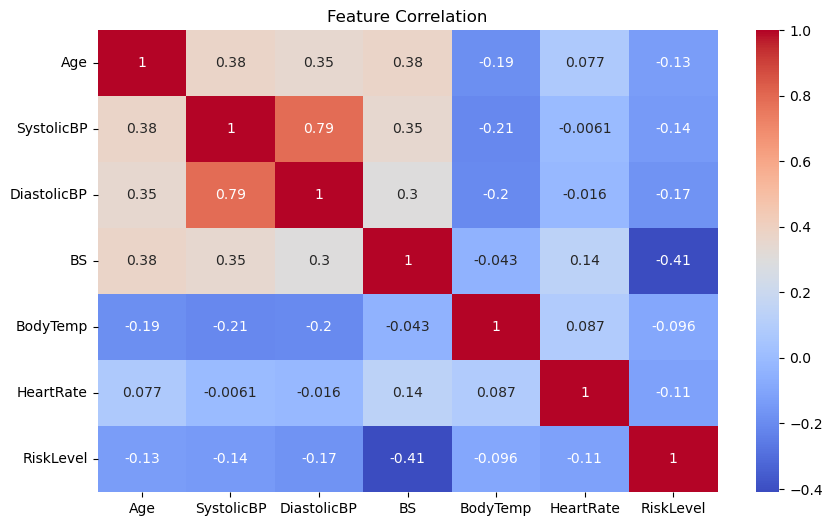

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

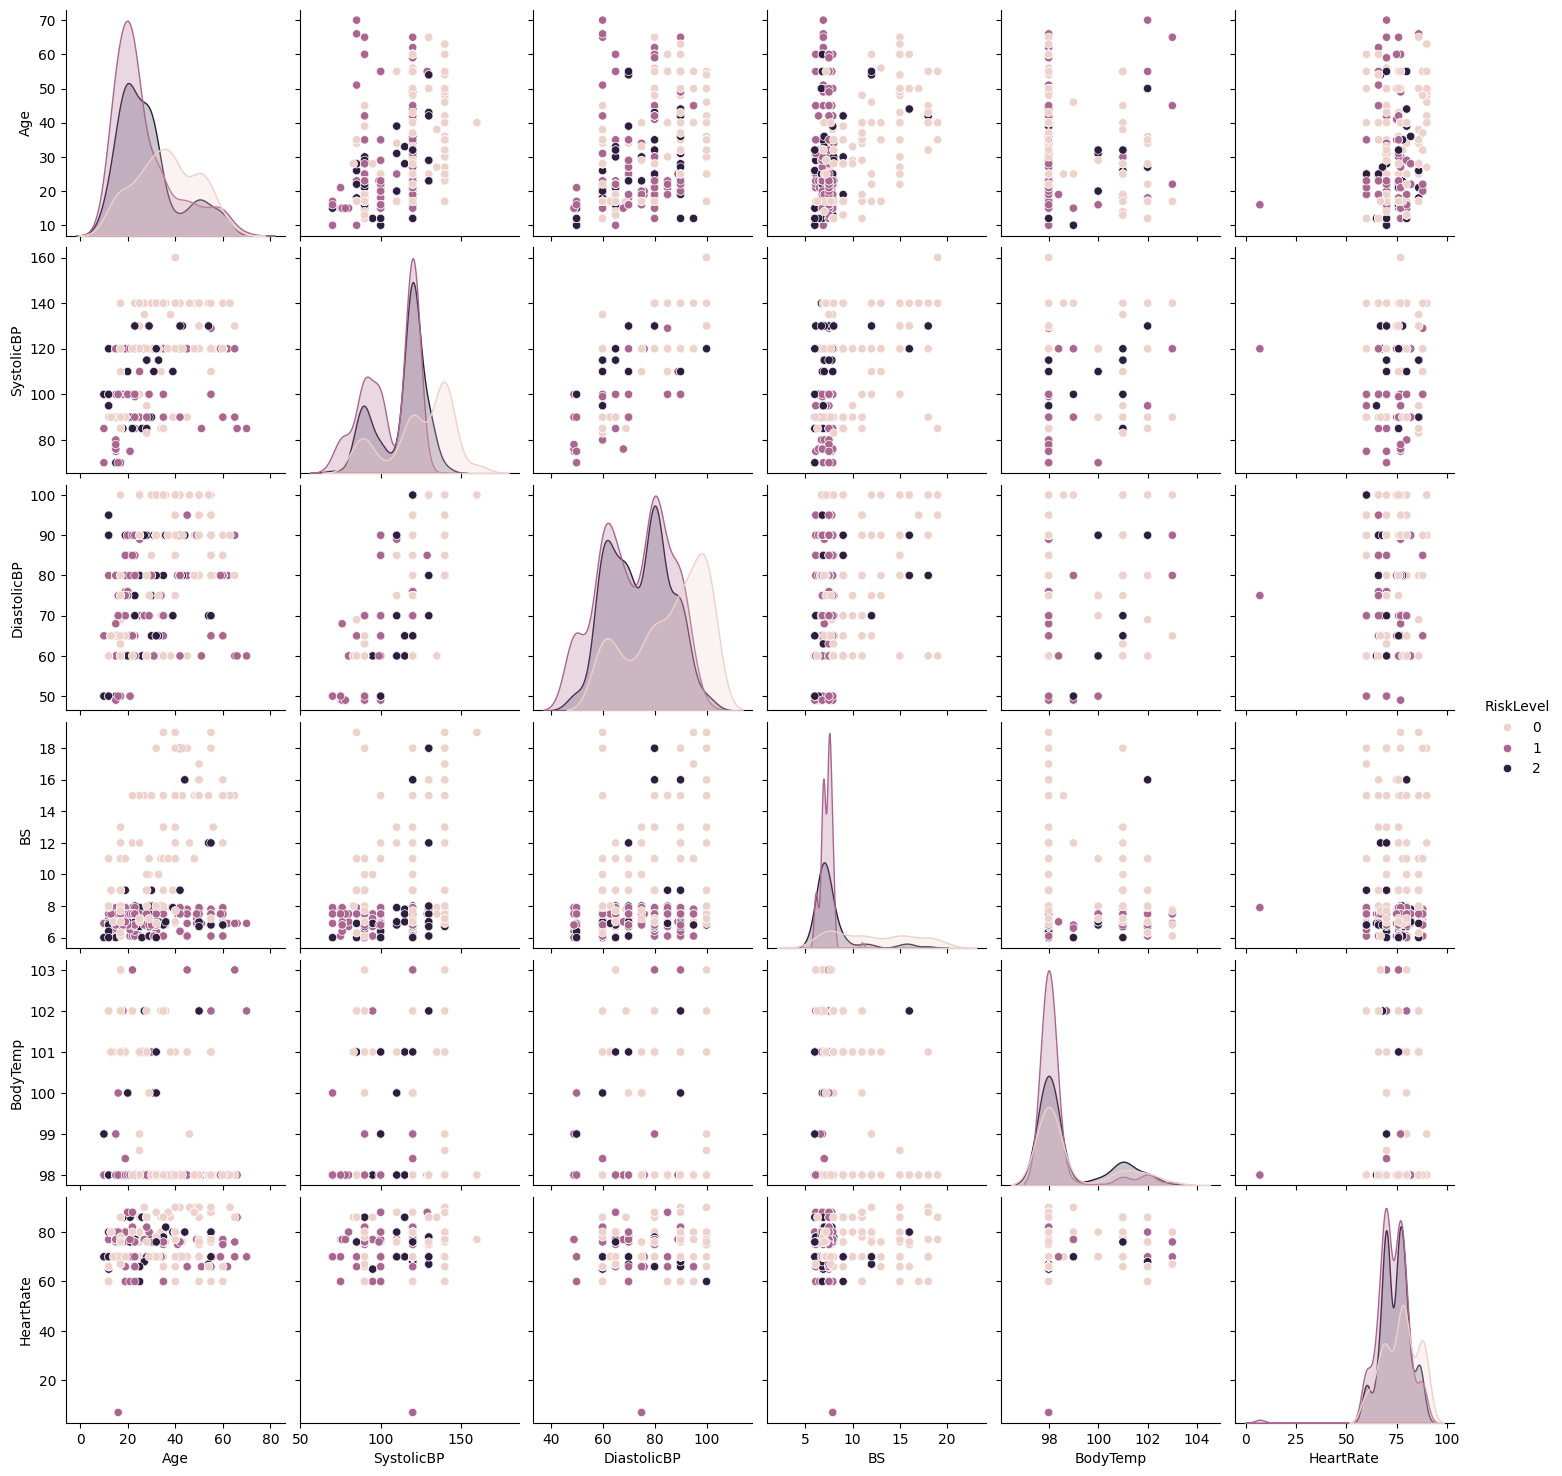

In [18]:
sns.pairplot(df, hue="RiskLevel")

plt.show()

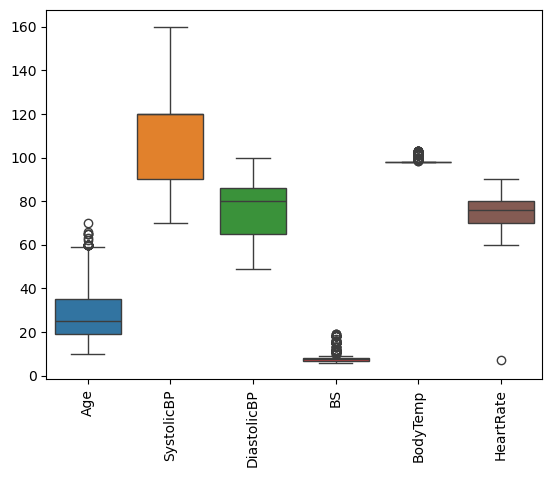

In [21]:
sns.boxplot(data=df)
plt.xticks(rotation = 'vertical')

plt.show()

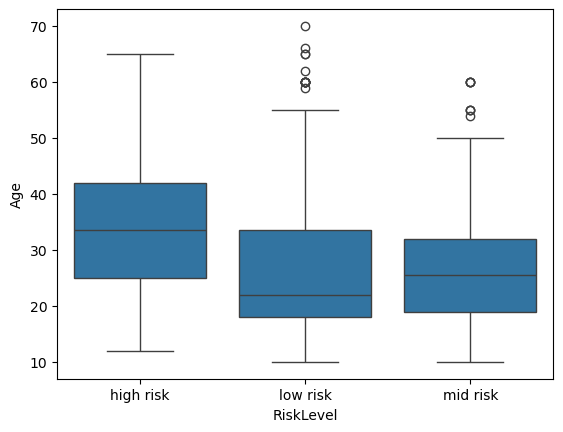

In [22]:
sns.boxplot(x="RiskLevel", y="Age", data=df)

plt.show()

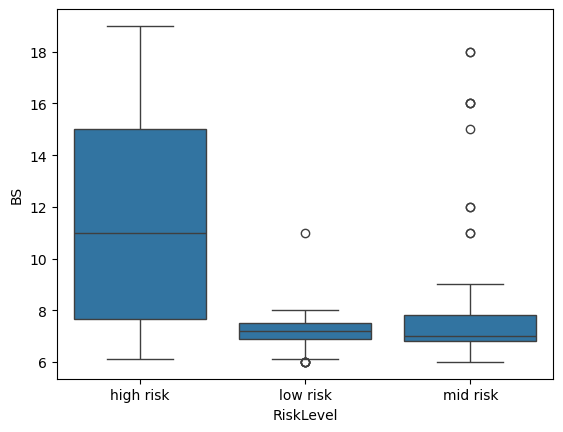

In [23]:
sns.boxplot(x="RiskLevel", y="BS", data=df)

plt.show()

## Feature Engnerring

In [40]:
le = LabelEncoder()

df["RiskLevel"] = le.fit_transform(df["RiskLevel"])

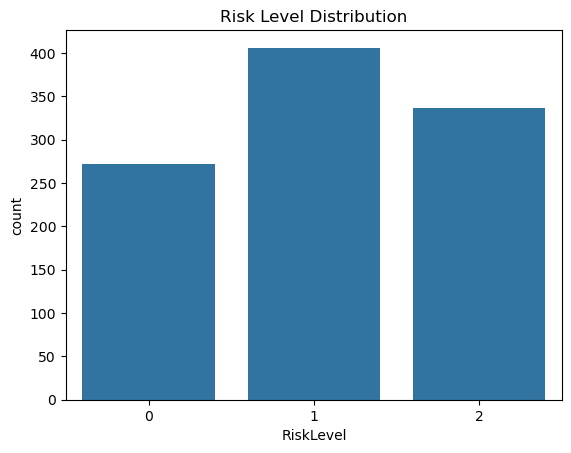

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="RiskLevel", data=df)

plt.title("Risk Level Distribution")

plt.show()

In [41]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,0
1,35,140,90,13.0,98.0,70,0
2,29,90,70,8.0,100.0,80,0
3,30,140,85,7.0,98.0,70,0
4,35,120,60,6.1,98.0,76,1


In [42]:
# new feature creating
df["BP_Diff"] = df["SystolicBP"] - df["DiastolicBP"]

df["Mean_BP"] = (df["SystolicBP"] + 2*df["DiastolicBP"]) / 3

df["HighBS"] = (df["BS"] > 8).astype(int)

df["Fever"] = (df["BodyTemp"] > 98.6).astype(int)

## Model Building

In [43]:
X = df.drop("RiskLevel", axis=1)

y = df["RiskLevel"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
model = ExtraTreesClassifier(

    n_estimators=1000,
    max_depth=20,
    min_samples_split=3,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [46]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8620689655172413


In [55]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=1200,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    random_state=42
)

xgb_model.fit(X_train, y_train)

pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.8719211822660099


In [56]:
import pickle
pickle.dump(xgb_model, open("xgb_model.pkl","wb"))

## Accuracy Metrices

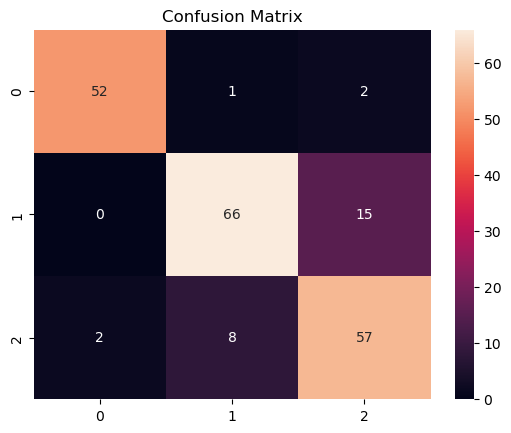

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        55
           1       0.88      0.81      0.85        81
           2       0.77      0.85      0.81        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203



In [50]:
accuracy_score(y_test, pred)

0.8719211822660099

In [51]:
precision_score(y_test, y_pred, average='weighted')

0.8662614338476409

In [52]:
recall_score(y_test, y_pred, average='weighted')

0.8620689655172413

In [53]:
f1_score(y_test, y_pred, average='weighted')

0.8629839336187314